In [1]:
import glob
import numpy as np
import seaborn as sns
import scanpy as sc
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix

from mmidas.cplMixVAE import cpl_mixVAE
from mmidas.utils.cluster_analysis import K_selection
from mmidas.eval import summarize_inference
from mmidas.utils.config_tools import get_paths
from mmidas.utils.data_tools import load_data, get_loaders, generate_colors, split_data_Kfold, select_best_genes

%load_ext autoreload
%autoreload 2

In [3]:
toml_file = 'pyproject.toml'
device = 'cpu'
config = get_paths(toml_file=toml_file)
data_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['Dbh_Retroseq_file']
data = load_data(file=data_file) 
print(data_file)

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...
Number of cells: 5133, Number of genes: 1841
/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/data/Dbh_Retroseq.h5ad


In [87]:
results_path = config['paths']['main_dir'] / config['paths']['saving_path']
available_models = glob.glob(str(results_path) + '/run_4*')

selected_model_file = available_models[-1]
trained_models = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_*')
# Get the model parameters from the selected model
param_vairables = selected_model_file.split('/')[-1].split('_')
params = {}
for p in range(0, len(param_vairables), 2):
    try:
        params[param_vairables[p]] = float(param_vairables[p+1])
        if params[param_vairables[p]] == int(params[param_vairables[p]]):
            params[param_vairables[p]] = int(params[param_vairables[p]])
    except ValueError:
        params[param_vairables[p]] = param_vairables[p+1]

params

{'run': 4,
 'Cdim': 15,
 'Sdim': 3,
 'Zdim': 10,
 'pdrop': 0.25,
 'fcdim': 100,
 'aug': 'True',
 'lr': 0.001,
 'narm': 2,
 'tau': 0.1,
 'nbatch': 1024,
 'nepoch': 10000,
 'nepochP': 10000,
 'dataset': 'all'}

In [88]:
print('Initializing mixvae model ...')
mixvae = cpl_mixVAE(saving_folder=selected_model_file, device=device)
mixvae.init_model(
                n_categories=params['Cdim'],
                state_dim=params['Sdim'],
                input_dim=data['log1p'].shape[1],
                fc_dim=params['fcdim'],
                lowD_dim=params['Zdim'],
                n_arm=params['narm'],
                tau=params['tau'],
                )


Initializing mixvae model ...
---> Using CPU!


In [89]:
seed = 0 
alldata_loader, train_loader, test_loader, _, _, _ = get_loaders(x=data['log1p'], batch_size=params['nbatch'], seed=seed)                                      

In [65]:
trained_models

['/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_4_Cdim_15_Sdim_2_Zdim_10_pdrop_0.25_fcdim_100_aug_True_lr_0.001_narm_2_tau_0.1_nbatch_1024_nepoch_10000_nepochP_10000_dataset_all/model/cpl_mixVAE_model_after_pruning_1_2025-01-31-16-10-36.pth',
 '/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_4_Cdim_15_Sdim_2_Zdim_10_pdrop_0.25_fcdim_100_aug_True_lr_0.001_narm_2_tau_0.1_nbatch_1024_nepoch_10000_nepochP_10000_dataset_all/model/cpl_mixVAE_model_after_pruning_3_2025-01-31-16-10-36.pth',
 '/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_4_Cdim_15_Sdim_2_Zdim_10_pdrop_0.25_fcdim_100_aug_True_lr_0.001_narm_2_tau_0.1_nbatch_1024_nepoch_10000_nepochP_10000_dataset_all/model/cpl_mixVAE_model_after_pruning_9_2025-01-31-16-10-36.pth',
 '/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_4_Cdim_15_Sdim_2_Zdim_10_pdrop_0.25_fcdim_100_aug_True_lr_0.001_nar

In [90]:
# Loading trained models including before pruning and after pruning
mixvae.variational = False
summary_dict = summarize_inference(mixvae, trained_models, alldata_loader)

Model /cpl_mixVAE_model_after_pruning_8_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_1_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_5_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_4_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_6_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_7_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_2_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_10_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_9_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_12_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_3_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_before_pruning_2025-01-31-16-38-07.pth


In [75]:
sum(outcome['pred_label'][0][1] == outcome['pred_label'][0][0]) / len(outcome['pred_label'][0][0])


np.float64(0.9779855834794468)

In [93]:
np.unique(outcome['pred_label'][0][1]), np.unique(outcome['pred_label'][0][0])

(array([ 2., 12., 13.]), array([ 2., 12., 13.]))

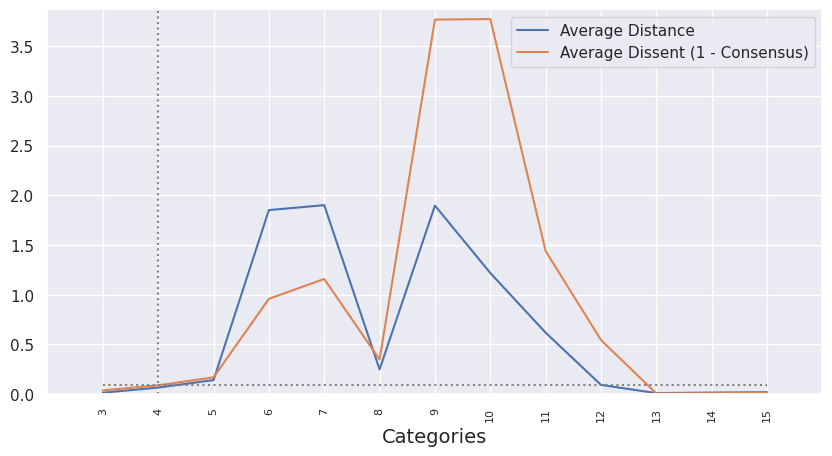

Selected number of clusters: 4 with consensus 0.9115526982271576


In [91]:
# Plotting average consensus measure to select the number of clusters according to the minimum consensus measure, here 0.95
_, _, _, model_order = K_selection(summary_dict, mixvae.n_categories, mixvae.n_arm, thr=0.95)

In [92]:
# model_order = 3
selected_model = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_after_pruning_' + str(mixvae.n_categories - model_order) + '*')[0]
mixvae.variational = True
outcome = summarize_inference(mixvae, selected_model, alldata_loader)

Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth


/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_56975/1653463318.py:6: RuntimeWarning: invalid value encountered in divide
  confm_E = arm_vs_arm / row_sum[:, np.newaxis]


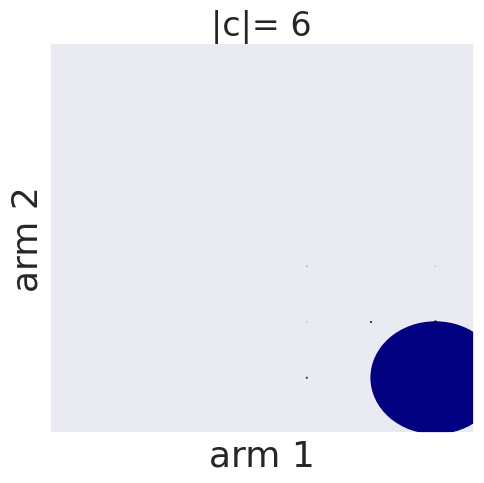

In [73]:
arm = 0
nprune_indx = outcome['nprune_indx']
arm_vs_arm = outcome['armA_vs_armB'][-1]
fig, axs = plt.subplots(1, 1, figsize=(5,5))
row_sum = arm_vs_arm.sum(axis=1)
confm_E = arm_vs_arm / row_sum[:, np.newaxis]
mtx = arm_vs_arm / np.max(arm_vs_arm) 
for l in range(model_order):
    for col in range(model_order):
        xy = np.array([col, l])
        axs.add_patch(plt.Circle(xy, radius=mtx[l, col], color='Navy'))
axs.set_xlim([-1, model_order - 0.4])
axs.set_ylim([-1, model_order])
axs.invert_yaxis()
axs.set_yticks([])
axs.set_xticks([])
axs.set_yticklabels([])
axs.set_xticklabels([])
plt.title('|c|= ' + str(arm_vs_arm.shape[0]), fontsize=24)
axs.set_xlabel('arm 1', fontsize=26)
axs.set_ylabel('arm 2', fontsize=26)
fig.tight_layout()
plt.savefig(selected_model_file + f'/consensus_T1_vs_T2_K_{model_order}.png', dpi=600)

Average consensus on test cells: 0.3195722919572292


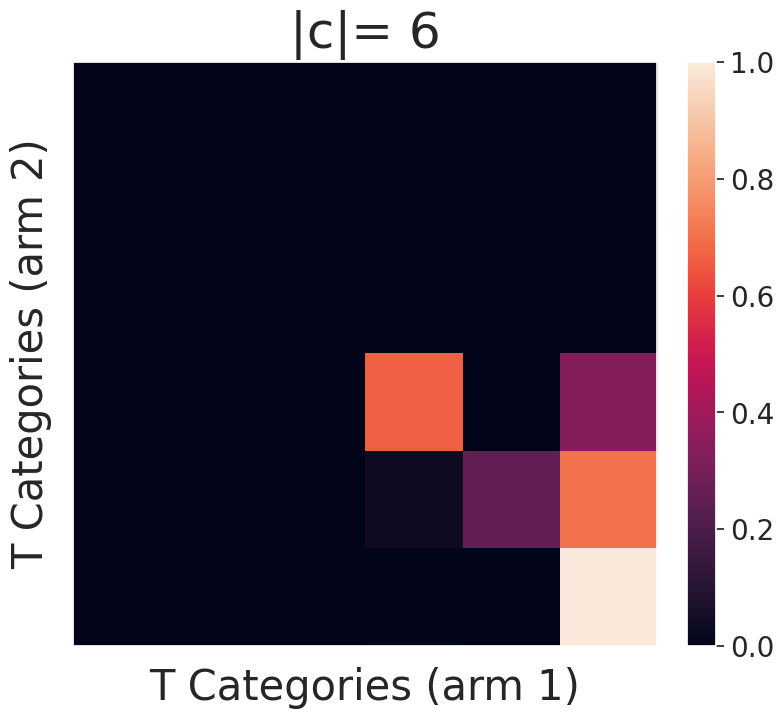

In [74]:
cons_mat = outcome['consensus'][0]

plt.figure(figsize=[8, 8])
ax = plt.gca()
im = ax.imshow(cons_mat, cmap='rocket', vmin=0, vmax=1)
plt.xlabel('T Categories (arm 1)', fontsize=30, labelpad=15)
plt.ylabel('T Categories (arm 2)', fontsize=30, labelpad=15)
plt.xticks([])
plt.yticks([])
plt.title('|c|= ' + str(cons_mat.shape[0]), fontsize=36, pad=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = plt.colorbar(im, cax=cax)
for t in cbar.ax.get_yticklabels():
     t.set_fontsize(20)
cons_lam = np.mean(np.diag(cons_mat)) 

plt.tight_layout()
plt.savefig(selected_model_file + f'/norm_consensus_T1_vs_T2_K_{model_order}.png', dpi=600)
print(f'Average consensus on test cells: {cons_lam}')

In [94]:
_, data_index = alldata_loader.dataset.tensors
data_index = data_index.numpy().astype(int)
predicted_label = outcome['pred_label'][0][0]
data["discrete_type"] = outcome['pred_label'][0][0]
unique_labels = np.unique(predicted_label)
colors = generate_colors(len(unique_labels))
cell_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each cell
for ic, c in enumerate(unique_labels):
    cell_colors[predicted_label == c] = colors[ic]

batch = np.unique(data['batch'])
colors = generate_colors(len(batch))
batch_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each batch
for ic, c in enumerate(batch):
    batch_colors[data['batch'] == c] = colors[ic]

external_donor_name = np.unique(data['external_donor_name'])
colors = generate_colors(len(external_donor_name))
donor_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each donor
for ic, c in enumerate(external_donor_name):
    donor_colors[data['external_donor_name'] == c] = colors[ic]

sex = np.unique(data['sex'])
colors = generate_colors(len(sex))
sex_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each sex
for ic, c in enumerate(sex):
    sex_colors[data['sex'] == c] = colors[ic]

roi = np.unique(data['injection_target'])
colors = generate_colors(len(roi))
roi_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each roi
for ic, c in enumerate(roi):
    roi_colors[data['injection_target'] == c] = colors[ic]
    
data_id = np.unique(data['dataset'])
colors = generate_colors(len(data_id))
dataset_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each roi
for ic, c in enumerate(data_id):
    dataset_colors[data['dataset'] == c] = colors[ic]


0


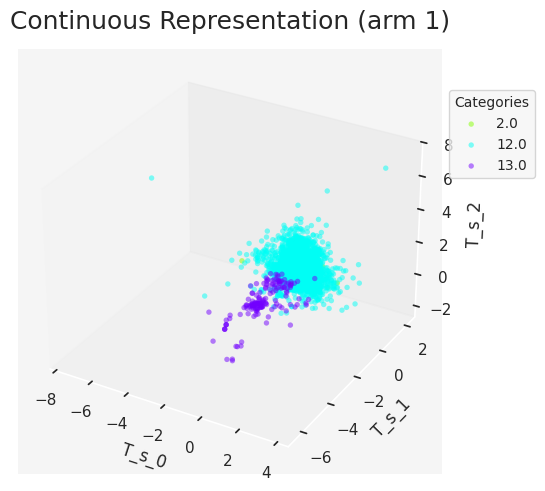

1


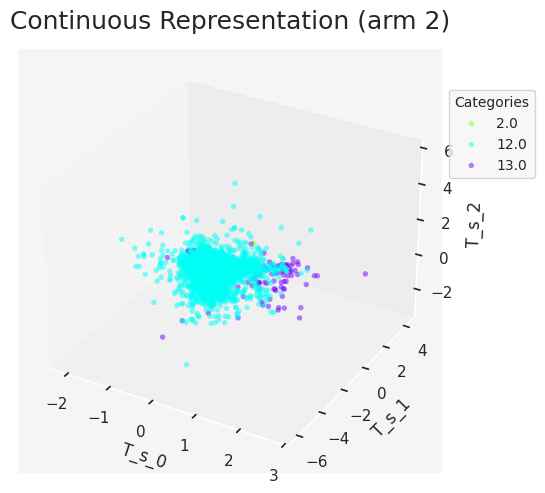

In [95]:
clr_var = cell_colors
label = predicted_label

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if  mixvae.state_dim > 2:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
    else:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
   

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .8), fontsize=10, title='Categories', title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


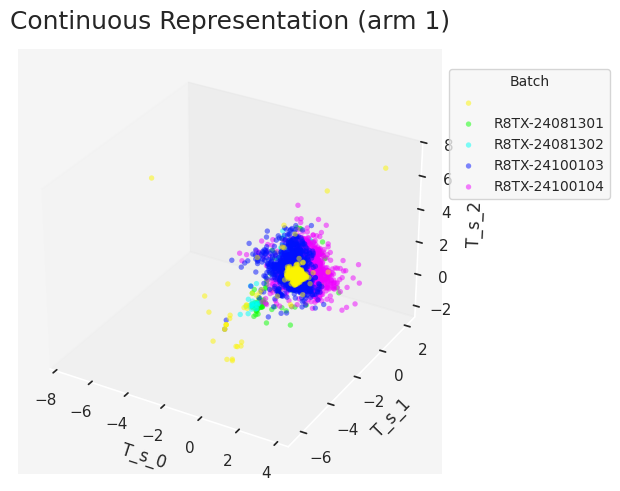

1


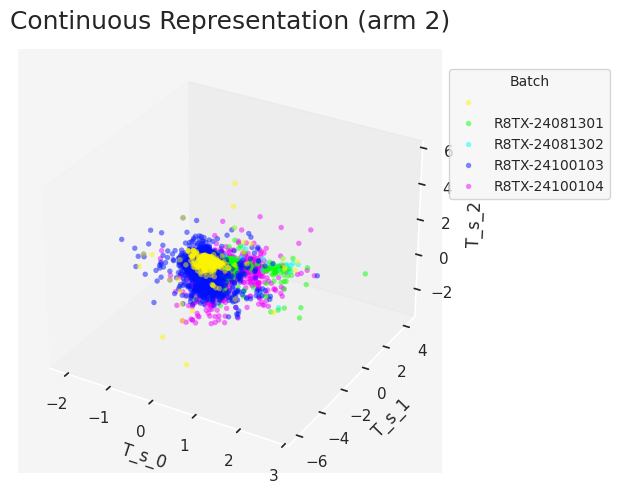

In [96]:
clr_var = batch_colors[data_index]
label = data['batch'][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(7, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})

    if mixvae.state_dim== 1:
        axs = fig.add_subplot(1, 1, 1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.hist(outcome['state_mu'][arm][indices, 0], color=clr, s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
    elif mixvae.state_dim == 2:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    elif mixvae.state_dim == 3:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .8), fontsize=10, title='Batch', title_fontsize=10)
    fig.tight_layout()
    plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


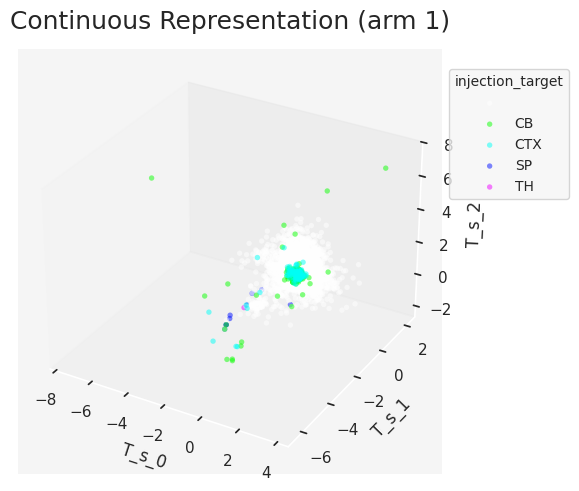

1


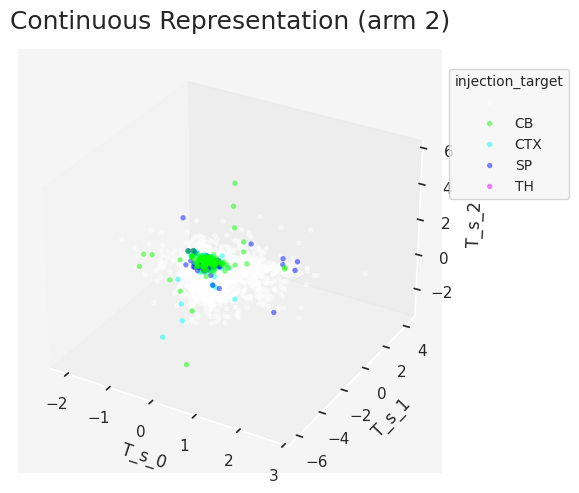

In [97]:
factor = 'injection_target'
clr_var = roi_colors[data_index]
clr_var[clr_var=='#fcf500'] = '#FFFFFF'
label = data[factor][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if mixvae.state_dim < 3:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    else:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .8), fontsize=10, title=factor, title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


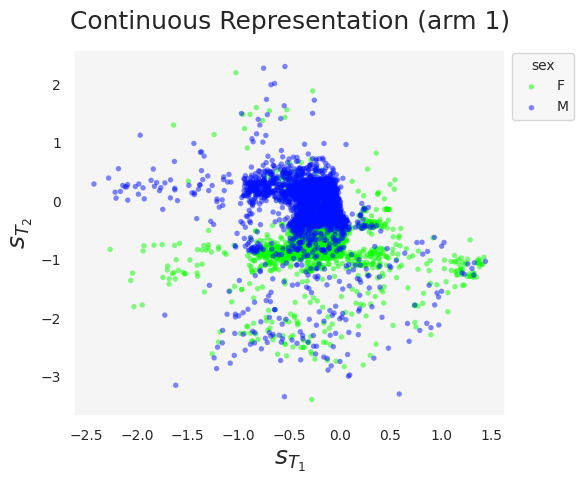

1


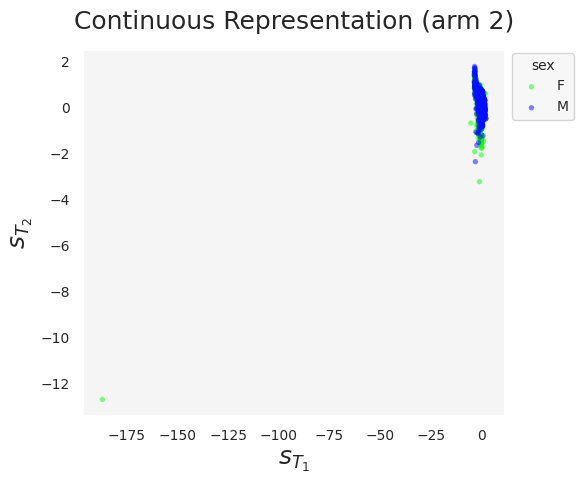

In [82]:
factor = 'sex'
clr_var = sex_colors[data_index]
label = data[factor][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if mixvae.state_dim < 3:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    else:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .9), fontsize=10, title=factor, title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


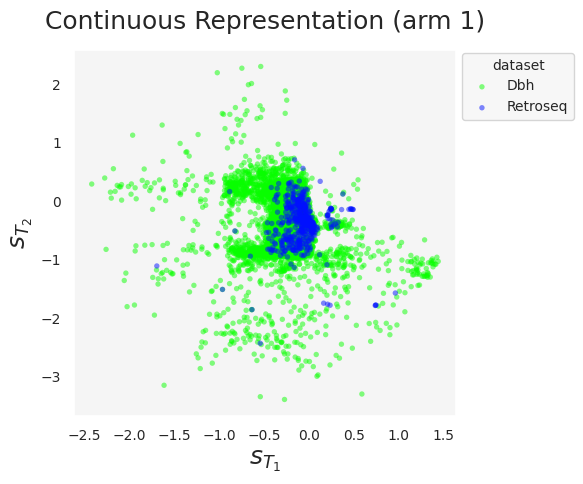

1


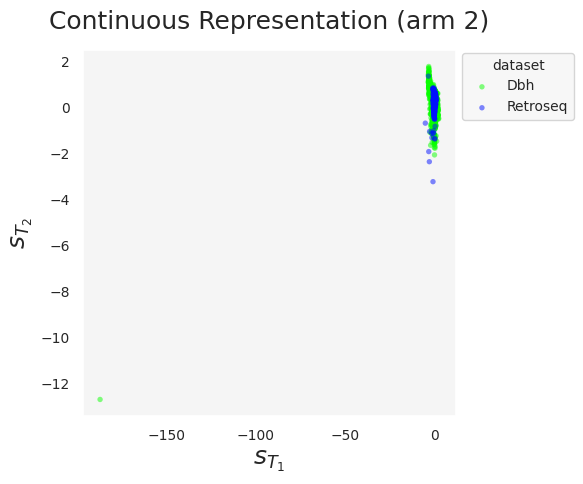

In [83]:
factor = 'dataset'
clr_var = dataset_colors[data_index]
# clr_var[clr_var=='#fcf500'] = '#cccccc'
label = data[factor][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'whitesmoke'})
    
    if mixvae.state_dim < 3:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    else:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(f'T_s_{0}')
        axs.set_ylabel(f'T_s_{1}')
        axs.set_zlabel(f'T_s_{2}')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=18, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .9), fontsize=10, title=factor, title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/Temp/ipykernel_56975/3393617754.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_.groupby(['Cell Type', 'Dataset']).size().unstack(fill_value=0)


[ 1. 12.]


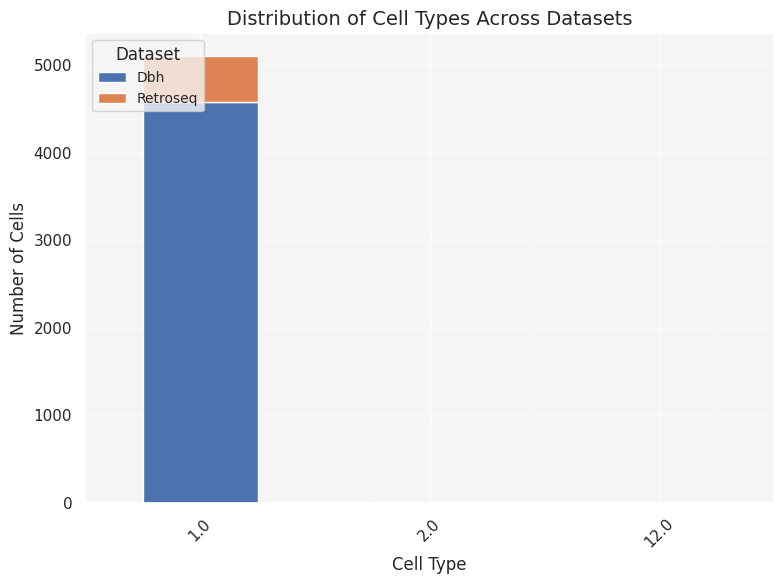

In [57]:
# Convert to a DataFrame
temp_dict = {'Cell Type': predicted_label, 'Dataset': data['dataset']}
df_ = pd.DataFrame(temp_dict)

# Aggregate data: count occurrences of each cell type in each dataset
counts = df_.groupby(['Cell Type', 'Dataset']).size().unstack(fill_value=0)

# Plot stacked bar chart
ax = counts.plot(kind='bar', stacked=True, figsize=(8, 6))

# Customize labels and title
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.title('Distribution of Cell Types Across Datasets', fontsize=14)
plt.legend(title='Dataset', loc='upper left', fontsize=10)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
print(df_[df_['Dataset'] == 'Retroseq']['Cell Type'].unique())

In [108]:
metadata = 'injection_target' #'discrete_type'
K_fold = 10

z = []
ref_label = []
for rep in range(10):
    outcome = summarize_inference(mixvae, selected_model, alldata_loader)
    ref_label.append(data[metadata][data[metadata] !=' '])
    z.append(outcome['state_sample'][0][data[metadata] !=' ', :])

z = np.concatenate(z, axis=0)
ref_label = np.concatenate(ref_label, axis=0)

n_feature = z.shape[1]
train_ind, test_ind = split_data_Kfold(ref_label, K_fold)
acc_T = []
acc_T_adj = []
pred_label = []
true_label = []

for fold in range(K_fold):
    print(f"------- {fold} -------")
    train_id = train_ind[fold].astype(int)
    test_id = test_ind[fold].astype(int)
    rfc = RandomForestClassifier()
    rfc.fit(z[train_id, :], ref_label[train_id])
    y_pred = rfc.predict(z[test_id, :])
    pred_label.append(y_pred)
    true_label.append(ref_label[test_id])
    acc_T.append(accuracy_score(ref_label[test_id], y_pred))
    acc_T_adj.append(balanced_accuracy_score(ref_label[test_id], y_pred))

print(f"{np.mean(acc_T)}, {np.mean(acc_T_adj)}")

true_label = np.concatenate(true_label)
pred_label = np.concatenate(pred_label)
conf_mat = confusion_matrix(true_label, pred_label, normalize='true')

unique_label = np.unique(true_label)

Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
Model /cpl_mixVAE_model_after_pruning_11_2025-01-31-16-38-07.pth
------- 0 -------
------- 1 -------
------- 2 -------
------- 3 -------
------- 4 -------
------- 5 -------
------- 6 -------
------- 7 -------
------- 8 -------
------- 9 -------
0.5253333333333333, 0.4174479648795457


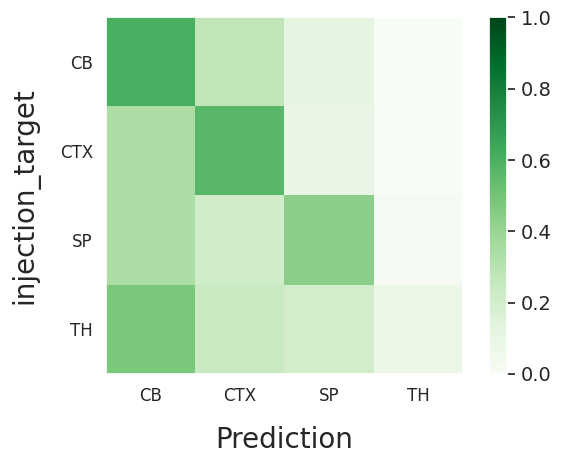

In [109]:
label = unique_label
eps = 0.01
plt.close('all')
plt.figure()
sns.set(font_scale=1.)
conf_mat[conf_mat < eps] = 0.
for row in range(conf_mat.shape[0]):
    conf_mat[row, np.argmax(conf_mat[row, :])] += 1 - sum(conf_mat[row, :])
    
plt.imshow(conf_mat, interpolation='nearest', cmap=plt.cm.Greens, vmax=1., vmin=0.)
cbar = plt.colorbar()
for t in cbar.ax.get_yticklabels():
    t.set_fontsize(14)

plt.xticks(np.arange(len(label)), label, fontsize=12)
plt.yticks(np.arange(len(label)), label, fontsize=12)

thresh = 0.5
plt.ylabel(metadata, fontsize=20, labelpad=15)
plt.xlabel('Prediction', fontsize=20, labelpad=15)
plt.grid(False)
plt.tight_layout()
plt.show()